In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import networkx as nx
import networkx.algorithms.shortest_paths.weighted as nx_weighted
import osmnx as ox
import pandas as pd
from tqdm import tqdm
from itertools import combinations, count, islice
from heapq import heappop, heappush
from math import radians, cos, sin, asin, sqrt
from pykml import parser
from jellyfish import jaro_similarity
from shapely.geometry import Point, LineString, Polygon
import folium

## Isofare Mapping: How far does your fare get you?

This project introduces the notion of "isofare" maps, inspired by isochrone maps, which show all points reachable from a given starting point within a certain period of time. Building on this concept, "isofare" maps show all points reachable from a given starting point for a certain cost. 

Which parts of the city are more cost-effectively connected by public transit? Given your starting location, how far does a $2.25 bus fare take you? When should you take a bikeshare over a bus?


In [3]:
CRS = 4326 #https://epsg.io/4326

In [4]:
WALK_SPEED_MPS = 1.4
WALK_MINUTES   = 10
WALK_RADIUS_M  = WALK_SPEED_MPS * WALK_MINUTES * 60

BIKE_SPEED_MPS = 4.0

In [5]:
BUDGET_LEVELS = [0.50, 1, 2.50, 5.00, 10.00]

Load OSMNx data

In [6]:
# setup for OSMNx data
CHI = "chi"
place = "Chicago, IL, USA"
city_data = {
    CHI: {"place": place},
}

In [8]:
mode = "walk"
city_mode = f"{CHI}_{mode}"
# uncomment to load data from osmnx and save
#graph = ox.graph_from_place(place, network_type=mode)
#ox.io.save_graphml(graph, f"./chi/{city_mode}.graphml")
graph = ox.io.load_graphml(filepath=f'./data/chi/{city_mode}.graphml')
# add time to city transit data
for source, dest, key, data in graph.edges(data=True, keys=True):
    data["time_s"] = data["length"] / WALK_SPEED_MPS
city_data[CHI][mode] = graph

In [9]:
mode = "bike"
city_mode = f"{CHI}_{mode}"
# uncomment to load data from osmnx and save
#graph = ox.graph_from_place(place, network_type=mode)
#ox.io.save_graphml(graph, f"./chi/{city_mode}.graphml")
graph = ox.io.load_graphml(filepath=f'./data/chi/{city_mode}.graphml')
for source, dest, key, data in graph.edges(data=True, keys=True):
    data["time_s"] = data["length"] / BIKE_SPEED_MPS
city_data[CHI][mode] = graph

In [10]:
# Helper functions defined in notebook 6

def make_color_legend(ax, colors, labels):
    lines = [
        mlines.Line2D(
            [0], [0], linestyle="none", marker="s",
            markersize=10, markerfacecolor=color
        )
        for color in colors
    ]
    ax.legend(lines, labels)


def plot_base_graph(graph, ax=None):
    return ox.plot_graph(
        graph,
        ax=ax,
        show=False,
        close=False,
        edge_color="#999999",
        edge_alpha=0.2,
        node_size=0,
        bgcolor="w",
    )

## CTA L Train

The CTA L uses a flat pricing structure, where passengers pay a flat fare of $2.50 for a single ride with up to two free transfers within two hours. Because of the radial layout of the L system, where all but one of the lines (the Yellow Line/Skokie Swift to Evanston) go through the Loop, any stop can be reached from any other stop with two transfers. Also, the end-to-end travel time for almost every line is under an hour, making it generally possible to reach any stop for $2.50. (Because of this, I didn't model time as a constraint for the L; this would be more relevant in more spread-out cities with a similar fare structure.)

In [11]:
# L stops (one row per stop — dedupe to one row per station)
l_stops = gpd.read_file("https://data.cityofchicago.org/resource/8pix-ypme.geojson?$limit=500")

l_stations = ( l_stops.drop_duplicates(subset="map_id")
.reset_index(drop=True)
.to_crs(CRS)
)

L_LINE_COLS = ["blue", "red", "green", "yellow", "brown", "purple", "pink", "orange"]
l_stations = l_stations.rename({
    "y": "yellow",
    "brn": "brown",
    "g": "green",
    "p": "purple",
    "pnk": "pink",
    "o": "orange"
}, axis=1)[["map_id", "stop_id", "station_name", "station_descriptive_name", *L_LINE_COLS, "geometry"]]

In [12]:
# identify the closest node on the street network
l_stations_nodes, dist_to_closest_node = ox.nearest_nodes(
    city_data[CHI]["walk"], l_stations.geometry.x, l_stations.geometry.y,
    return_dist=True
)
l_stations = l_stations.assign(closest_node=l_stations_nodes, dist_to_closest_node=dist_to_closest_node)
l_stations.head()

,map_id,stop_id,station_name,station_descriptive_name,blue,red,green,yellow,brown,purple,pink,orange,geometry,closest_node,dist_to_closest_node
0,40830,30162,18th,18th (Pink Line),False,False,False,False,False,False,True,False,POINT (-87.66915 41.85791),13847342228,4.008438
1,40120,30022,35th/Archer,35th/Archer (Orange Line),False,False,False,False,False,False,False,True,POINT (-87.68062 41.82935),13375154652,6.269896
2,41120,30213,35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),False,False,True,False,False,False,False,False,POINT (-87.62583 41.83168),4606976494,13.616276
3,41270,30245,43rd,43rd (Green Line),False,False,True,False,False,False,False,False,POINT (-87.61902 41.81646),10224541416,7.995902
4,41080,30210,47th,47th (Green Line),False,False,True,False,False,False,False,False,POINT (-87.61883 41.80921),10245915314,7.997913


Below we define several helper dictionaries for quick lookups between L stops and L lines, geometry and nodes.

In [13]:
l_stop_coords = {
    row["station_descriptive_name"]: (row["geometry"].y, row["geometry"].x)
    for _, row in l_stations.iterrows()
}

l_station_to_lines_dict = {
    row["station_descriptive_name"]: [line for line in L_LINE_COLS if row[line]]
    for _, row in l_stations.iterrows()
}
# O'Hare surcharge flag
l_station_to_lines_dict["O'Hare (Blue Line)"].append("ORD")

l_lines_to_stations_dict = {
    line: l_stations[l_stations[line]]["station_descriptive_name"].tolist()
    for line in L_LINE_COLS
}
l_lines_to_stations_dict["ORD"] = ["O'Hare (Blue Line)"]

l_station_to_node_dict = l_stations.set_index("station_descriptive_name")["closest_node"].to_dict()
node_to_l_station_dict = l_stations.set_index("closest_node")["station_descriptive_name"].to_dict()
nx.set_node_attributes(city_data[CHI]["walk"], node_to_l_station_dict, name="l_station_name")

I modeled the L network as a graph where each line is a node. I have also chosen to model the O'Hare Blue Line stop,, which is the terminal stop of the Blue Line at O'Hare Intl Airport, as its own node, because journeys from O'Hare cost $5 instead of the standard $2.50. Each edge represents a transfer between lines, to model the reach of your "transfer budget"; all nodes are reachable with a "transfer budget" of 2.

In [14]:
# L line graph - edges represent lines that share a station
l_lines_graph = nx.complete_graph(L_LINE_COLS)
for line in [l for l in L_LINE_COLS if l not in ["yellow", "red", "purple"]]:
    l_lines_graph.remove_edge("yellow", line)
l_lines_graph.add_node("ORD")
l_lines_graph.add_edge("blue", "ORD")

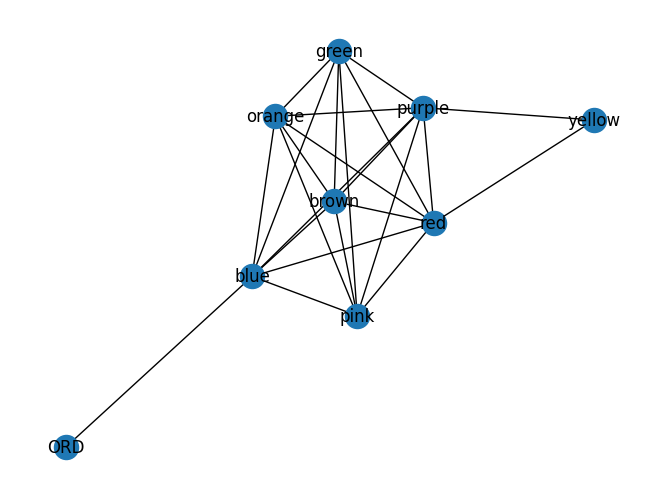

In [15]:
nx.draw(l_lines_graph, with_labels=True)

## CTA Buses

CTA buses share the same flat pricing structure, with a single bus journey costs $2.25 with two free transfers within two hours.

In [98]:
# bus data
cta_bus_routes = gpd.read_file("https://data.cityofchicago.org/resource/6uva-a5ei.geojson").to_crs(CRS)

In [99]:
bus_routes_graph = nx.Graph()
bus_routes_graph.add_nodes_from(cta_bus_routes["route"])

In [100]:
# local file, too many rows to download via API - available on github
cta_bus_stops = gpd.read_file("data/chi/CTA_BusStops_20260528.zip")
cta_bus_stops["routes"] = cta_bus_stops["routesstpg"].str.split(",")
cta_bus_stops = cta_bus_stops[cta_bus_stops["routes"].notna()].to_crs(CRS)

In [101]:
# identify the closest node on the street network
bus_stop_nodes, bus_dist_to_closest = ox.nearest_nodes(
    city_data[CHI]["walk"],
    cta_bus_stops.geometry.x, cta_bus_stops.geometry.y,
    return_dist=True,
)
cta_bus_stops = cta_bus_stops.assign(
    closest_node=bus_stop_nodes,
    dist_to_closest_node=bus_dist_to_closest,
)

In [102]:
bus_stop_coords = {
    row.public_nam: (row.geometry.y, row.geometry.x)
    for _, row in cta_bus_stops.iterrows()
}

bus_stops_dict  = {} 
bus_routes_dict = {} 

valid_routes = set(cta_bus_routes["route"])

for _, stop in cta_bus_stops.iterrows():
    clean_routes = [r for r in stop.routes if r in valid_routes]
    if not clean_routes:
        continue

    bus_stops_dict[stop.public_nam] = bus_stops_dict.get(stop.public_nam, []) + clean_routes
    for route in clean_routes:
        bus_routes_dict[route] = bus_routes_dict.get(route, []) + [stop.public_nam]
    for pair in combinations(clean_routes, r=2):
        bus_routes_graph.add_edge(*pair)

bus_stops_dict = {k: list(set(v)) for k, v in bus_stops_dict.items()}

nx.set_node_attributes(bus_routes_graph, bus_routes_dict, name="stops")

bus_stop_to_node_dict = cta_bus_stops.set_index("public_nam")["closest_node"].to_dict()
node_to_bus_stop_dict = cta_bus_stops.set_index("closest_node")["public_nam"].to_dict()
nx.set_node_attributes(city_data[CHI]["walk"], node_to_bus_stop_dict, name="bus_stop_name")

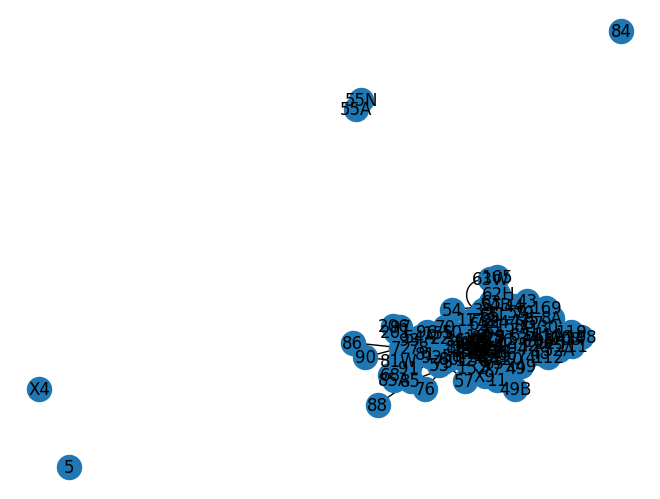

In [104]:
# Visual check that bus_routes_graph looks reasonable:
nx.draw(bus_routes_graph, with_labels=True)

In [22]:
cta_bus_stops.head()

,systemstop,street,cross_st,dir,pos,routesstpg,owlroutes,city,public_nam,geometry,routes,closest_node,dist_to_closest_node
0,15189.0,CICERO,BERTEAU (north leg),SB,FS,"54,54A",NaN,CHICAGO,Cicero & Berteau,POINT (-87.74751 41.95689),"[54, 54A]",2185494689,7.751686
1,14545.0,HALSTED,119TH STREET,NB,FS,"8A,108",NaN,CHICAGO,Halsted & 119th Street,POINT (-87.64179 41.67799),"[8A, 108]",4332986840,20.175176
2,15046.0,KEDZIE,TOUHY,NB,FS,11,NaN,CHICAGO,Kedzie & Touhy,POINT (-87.70897 42.01205),[11],9952999184,0.644070
3,6280.0,ASHLAND,IRVING PARK,NB,NS,"9,X9",NaN,CHICAGO,Ashland & Irving Park,POINT (-87.66892 41.95419),"[9, X9]",10005669815,2.542734
4,4484.0,ARCHER,DAMEN,SWB,NS,62,N62,CHICAGO,Archer & Damen,POINT (-87.67518 41.83201),[62],10091627212,2.912963


## Metra Trains

The Metra train network serves the area around Chicago, and has a zone pricing structure, with fares increasing for longer journeys. 

In [23]:
#https://www.google.com/maps/d/u/0/viewer?mid=1DgjdcmNOBkOb2sNkZniUMfchyWrjuu0&ll=42.00505398907377%2C-88.08259&z=9

with open("data/chi/Metra Stations by Fare Zone (Since 2024).kml", 'r', encoding="utf-8") as f:
    root = parser.parse(f).getroot()

stations = []
for folder in root.Document.Folder:
    zone_name = folder.name.text
    for placemark in folder.Placemark:
        coords_raw = placemark.Point.coordinates.text.strip()
        lon, lat, _ = coords_raw.split(",")
        stations.append({
            "name": placemark.name.text,
            "zone": zone_name,
            "lat": float(lat),
            "lon": float(lon),
        })

metra_stations_raw = pd.DataFrame(stations)
print(metra_stations_raw)

                         name    zone        lat        lon
0               Union Station  Zone 1  41.879286 -87.638976
1            Van Buren Street  Zone 1  41.877113 -87.623017
2          Millennium Station  Zone 1  41.883670 -87.623205
3    Museum Campus / 11th St.  Zone 1  41.868458 -87.621541
4              LaSalle Street  Zone 1  41.876237 -87.632204
..                        ...     ...        ...        ...
236              Libertyville  Zone 4  42.291047 -87.956216
237             Fort Sheridan  Zone 4  42.217394 -87.821115
238                 New Lenox  Zone 4  41.514536 -87.965225
239                    Aurora  Zone 4  41.759471 -88.309103
240                    Elburn  Zone 4  41.890746 -88.464135

[241 rows x 4 columns]


In [24]:
metra_stations_raw["geometry"] = metra_stations_raw.apply(
    lambda r: Point(r["lon"], r["lat"]), axis=1
)
metra_stations_raw = gpd.GeoDataFrame(metra_stations_raw, geometry="geometry", crs=CRS)


In [25]:
# this file contains the lines and geometries for each station
metra_shapefile = gpd.read_file("data/chi/Metra_Stations.zip")

The two Metra datasets don't have an exact column to join on; here, I join on a combination of spatial and name matching, with some manual pruning to remove duplicate matches (eg 91st Street matches with both 91st Street and 95th Street).

In [26]:
sjoin_distance      = 0.007
jaro_score_cutoff   = 0.85

joined = metra_shapefile.to_crs(CRS).sjoin(
    metra_stations_raw, distance=sjoin_distance, predicate="dwithin"
)
joined = joined[["LONGNAME", "name", "STATION_ID", "LINES", "zone", "lat", "lon"]]
joined["jaro_score"] = joined.apply(
    lambda r: jaro_similarity(r["LONGNAME"], r["name"]), axis=1
)


In [27]:
# save to a csv to see the output and remove duplicates
joined[joined["jaro_score"] > jaro_score_cutoff].sort_values("LONGNAME").to_csv("/data/check_metra_names.csv")

In [28]:
metra_line_zones = gpd.read_file("./data/matched_metra_stations.csv") # my edited csv
metra_line_zones["geometry"] = metra_line_zones.apply(
    lambda r: Point(float(r["lon"]), float(r["lat"])), axis=1
)
metra_line_zones = (
    metra_line_zones
    .set_geometry("geometry", crs=CRS)
    [["STATION_ID", "name", "LINES", "zone", "geometry"]]
    .rename(columns={"LINES": "line"})
    .set_index("STATION_ID")
)

In [29]:
# identify the closest node on the street network
metra_stop_nodes, metra_dist_to_closest = ox.nearest_nodes(
    city_data[CHI]["walk"],
    metra_line_zones.geometry.x, metra_line_zones.geometry.y,
    return_dist=True,
)
metra_line_zones = metra_line_zones.assign(
    closest_node=metra_stop_nodes,
    dist_to_closest_node=metra_dist_to_closest,
)
# Null out nodes that are too far away to be reliable snaps
metra_line_zones.loc[metra_line_zones["dist_to_closest_node"] >= 100, "closest_node"]        = None
metra_line_zones.loc[metra_line_zones["dist_to_closest_node"] >= 100, "dist_to_closest_node"] = None

metra_line_zones["lines"] = metra_line_zones["line"].str.split(", ")

In [30]:
LINE_COLS = ["Rock Is.", "Electric", "SWS", "S. Shore", "NCS", 
             "UP-NW", "BNSF", "Milw-W", "UP-W", "UP-N", "Milw-N", "Heritage"]


for line in LINE_COLS:
    metra_line_zones[line] = metra_line_zones["lines"].apply(
        lambda l: line in l
    )

In [31]:
metra_stop_coords = {
    row["name"]: (row["geometry"].y, row["geometry"].x)
    for _, row in metra_line_zones.iterrows()
}

In [32]:
metra_station_to_node_dict = metra_line_zones.dropna(subset=["closest_node"]).set_index("name")["closest_node"].to_dict()
node_to_metra_station_dict = metra_line_zones.dropna(subset=["closest_node"]).set_index("closest_node")["name"].to_dict()

nx.set_node_attributes(city_data[CHI]["walk"], node_to_metra_station_dict, name="metra_station_name")

Visualize the Metra map:

<Axes: >

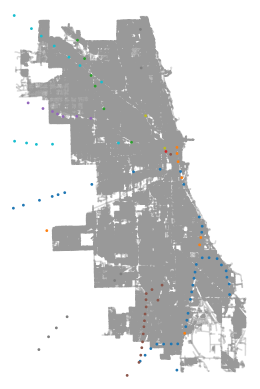

In [33]:
fig, ax = plt.subplots()
plot_base_graph(city_data[CHI]["walk"], ax=ax)
metra_line_zones.plot(ax=ax, column="line", markersize=1)

I manually created the edge list from the fare information. Longer journeys are more expensive.

In [34]:
metra_fares = pd.read_csv("data/chi/metra_zone_fares.csv")
metra_fares

,source,target,fare
0,Zone 1,Zone 2,3.75
1,Zone 1,Zone 3,5.50
2,Zone 1,Zone 4,6.75
3,Zone 2,Zone 3,3.75
4,Zone 2,Zone 4,3.75
5,Zone 3,Zone 4,3.75
6,Zone 1,Zone 1,3.75
7,Zone 2,Zone 2,3.75
8,Zone 3,Zone 3,3.75
9,Zone 4,Zone 4,3.75


In [35]:
metra_fare_graph = nx.from_pandas_edgelist(metra_fares, edge_attr=True)

# Add self-loops so intra-zone lookup doesn't KeyError
for zone in metra_fare_graph.nodes:
    metra_fare_graph.add_edge(zone, zone, fare=0.0)

{('Zone 1', 'Zone 2'): Text(0.5184052995999258, 0.48106870305739835, '3.75'),
 ('Zone 1', 'Zone 3'): Text(0.4804942094675264, -0.5189378116816746, '5.5'),
 ('Zone 1',
  'Zone 4'): Text(1.8426402006443965e-06, -6.986786904583653e-08, '6.75'),
 ('Zone 1', 'Zone 1'): Text(0.9989055357219008, 0.1621243046165064, '0.0'),
 ('Zone 2',
  'Zone 3'): Text(-4.4209635485792376e-07, -1.1659518222906229e-05, '3.75'),
 ('Zone 2', 'Zone 4'): Text(-0.48049413185610623, 0.518937883701539, '3.75'),
 ('Zone 2', 'Zone 2'): Text(0.03791719439800545, 1.1999999999999749, '0.0'),
 ('Zone 3', 'Zone 4'): Text(-0.5184174305199789, -0.4810556015591335, '3.75'),
 ('Zone 3', 'Zone 3'): Text(-0.03791719439826702, -0.7999999999997713, '0.0'),
 ('Zone 4', 'Zone 4'): Text(-0.9989055357216371, 0.23787569538318842, '0.0')}

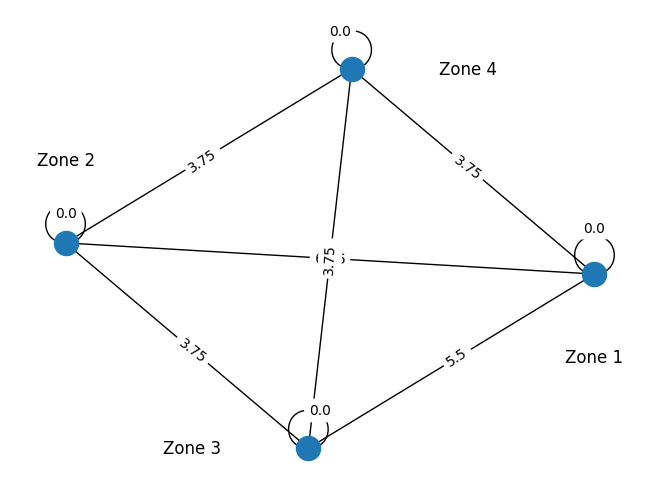

In [36]:
nx.draw(metra_fare_graph)
nx.draw_networkx_labels(metra_fare_graph, pos=nx.spring_layout(metra_fare_graph))
edge_labels = nx.get_edge_attributes(metra_fare_graph, "fare") 
nx.draw_networkx_edge_labels(metra_fare_graph, pos=nx.spring_layout(metra_fare_graph), edge_labels=edge_labels)

## Bikeshare: Divvy

In [37]:
# read in station data
divvy_stations = gpd.read_file("data/chi/Divvy Bicycle Stations_20260520.zip")
divvy_stations = divvy_stations.to_crs(CRS)

In [107]:
# identify the closest node on the street network
divvy_walk_nodes, dist_to_closest_node = ox.nearest_nodes(
    city_data[CHI]["walk"], divvy_stations.geometry.x, divvy_stations.geometry.y,
    return_dist=True
)
# identify the closest node on the bike network
divvy_bike_nodes, dist_to_closest_node = ox.nearest_nodes(
    city_data[CHI]["bike"], divvy_stations.geometry.x, divvy_stations.geometry.y,
    return_dist=True
)
divvy_stations = divvy_stations.assign(
    closest_node=divvy_walk_nodes,          
    dist_to_closest_node=dist_to_closest_node,
    closest_bike_node=divvy_bike_nodes,      
)
divvy_stations.head()

,id,station_na,short_name,total_dock,docks_in_s,status,latitude,longitude,geometry,closest_node,dist_to_closest_node,closest_bike_node
0,1859717767703464460,Kedzie Ave & Redfield Dr,CHI01795,15.0,15.0,In Service,41.765230,-87.703160,POINT (-87.70316 41.76523),2373184965,19.137965,10283919529
1,a3a95142-a135-11e9-9cda-0a87ae2ba916,Lincoln Ave & Waveland Ave,CHI00446,15.0,15.0,In Service,41.948797,-87.675278,POINT (-87.67528 41.9488),10187562047,16.925718,1536820572
2,1890602768178733256,Leclaire Ave & Belmont Ave,CHI01764,15.0,15.0,In Service,41.939041,-87.754197,POINT (-87.7542 41.93904),4957753257,17.332150,4957753257
3,a3a6f2a2-a135-11e9-9cda-0a87ae2ba916,Damen Ave & Clybourn Ave,CHI00348,15.0,15.0,In Service,41.932210,-87.678590,POINT (-87.67859 41.93221),13547448853,23.139786,260099111
4,1936560699993133354,Artesian Ave & 55th St,CHI01923,15.0,15.0,In Service,41.794020,-87.685770,POINT (-87.68577 41.79402),13271333274,19.931084,1402600487


In [108]:
divvy_station_to_node_dict = divvy_stations.set_index("station_na")["closest_bike_node"].to_dict()
node_to_divvy_station_dict = divvy_stations.set_index("closest_bike_node")["station_na"].to_dict()
nx.set_node_attributes(city_data[CHI]["walk"], node_to_divvy_station_dict, name="divvy_station_name")

<Axes: >

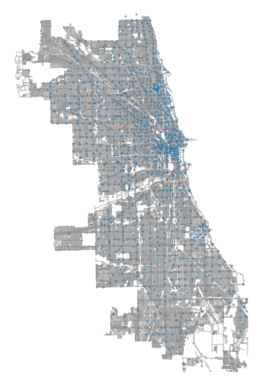

In [66]:
fig, ax = plt.subplots()

plot_base_graph(city_data[CHI]["bike"], ax=ax)
divvy_stations.plot(ax=ax, markersize=0.1)

In [48]:
def divvy_cost_function(time_s):
    return 1 + (0.20 * (time_s / 60))

my_cost_function = divvy_cost_function

In [41]:
# @markdown This cell redefines a function inside of the NetworkX ego_graph method to allow us to use 
# @markdown a custom weight function instead of just the sum of the weights in checking if we have passed
# @markdown the cutoff. Here, I have inserted the divvy cost function which returns price as a function of 
# @markdown time.

def my_dijkstra_multisource(
    G, sources, weight, pred=None, paths=None, cutoff=None, target=None
):
    """
    Dijkstra's algorithm patched to apply divvy_cost_function to the
    cumulative edge-weight before comparing against the fare cutoff.
    All other logic is identical to the NetworkX original.
    """
    pred_dict = pred if paths is None or pred is not None else {}
    G_succ = G._adj
    dist  = {}
    seen  = {}
    c     = count()
    fringe = []
    for source in sources:
        seen[source] = 0
        heappush(fringe, (0, next(c), source))
    number_of_sources = len(seen)

    while fringe:
        (dist_v, _, v) = heappop(fringe)
        if v in dist:
            continue
        dist[v] = dist_v
        if v == target:
            break
        for u, e in G_succ[v].items():
            cost = weight(v, u, e)
            if cost is None:
                continue
            vu_dist = dist_v + cost
            if cutoff is not None and divvy_cost_function(vu_dist) > cutoff:
                continue
            if u in dist:
                if vu_dist < dist[u]:
                    raise ValueError("Contradictory paths found: negative weights?")
                elif pred is not None and vu_dist == dist[u]:
                    pred_dict[u].append(v)
            elif u not in seen or vu_dist < seen[u]:
                seen[u] = vu_dist
                heappush(fringe, (vu_dist, next(c), u))
                if pred_dict is not None:
                    pred_dict[u] = [v]
            elif pred is not None and vu_dist == seen[u]:
                pred_dict[u].append(v)

    if paths is not None:
        if target is None:
            for v in islice(dist, number_of_sources, None):
                paths[v] = paths[pred_dict[v][0]] + [v]
        else:
            path = paths[target] = [target]
            while (current_preds := pred_dict.get(path[-1])) is not None:
                path.append(current_preds[0])
            path.reverse()

    return dist


nx_weighted._dijkstra_multisource = my_dijkstra_multisource

In [67]:
# @markdown Helper function from notebook 6: 
# @markdown This cell defines `make_convex_hull_isochrones`, which builds
# @markdown convex-hull isochrone polygons from a graph and a set of starting nodes.
# @markdown We'll use it for walking below, and again for biking and driving.


def make_convex_hull_isochrones(graph, node_array, fare_costs):
    isochrone_polys = {t: [] for t in fare_costs}
    for node in tqdm(node_array):
        for cost in sorted(fare_costs, reverse=True):
            egograph = nx.ego_graph(graph, node, radius=cost, distance="time_s")
            subgraph = egograph.subgraph(divvy_bike_nodes)
            node_points = [
                Point((data["x"], data["y"])) for _, data in subgraph.nodes(data=True)
            ]
            isochrone_polys[cost].append(
                gpd.GeoSeries(node_points).union_all().convex_hull
            )
    return isochrone_polys

In [68]:
# A helper function to convert the isochrone polygons into a geodataframe
def polys_to_gdf(isochrone_polys, fare_costs, crs=CRS):
    gdf_list = []
    for cost in fare_costs:
        gdf = gpd.GeoDataFrame(geometry=isochrone_polys[cost], crs=crs)
        gdf["cost"] = cost
        gdf_list.append(gdf)

    output_gdf = pd.concat(gdf_list, ignore_index=True)
    return output_gdf

In [76]:
# choose some nodes:
node_array = divvy_bike_nodes[40:45]

graph = city_data[CHI]["bike"]
fare_costs = [0.5, 2, 5]

In [77]:
isochrone_polys = make_convex_hull_isochrones(graph, node_array, fare_costs)
isochrone_gdf = polys_to_gdf(isochrone_polys, fare_costs)
isochrone_gdf


100%|██████████| 5/5 [00:01<00:00,  3.51it/s]


,geometry,cost
0,POINT (-87.6506 41.939),0.5
1,POINT (-87.531 41.73809),0.5
2,POINT (-87.64845 41.89174),0.5
3,POINT (-87.67824 41.93593),0.5
4,POINT (-87.65874 41.69945),0.5
5,"POLYGON ((-87.64427 41.93134, -87.65262 41.932...",2.0
6,POINT (-87.531 41.73809),2.0
7,"POLYGON ((-87.64974 41.88312, -87.6533 41.8855...",2.0
8,"POLYGON ((-87.67886 41.93227, -87.6832 41.9395...",2.0
9,"POLYGON ((-87.66899 41.69927, -87.6567 41.7049...",2.0


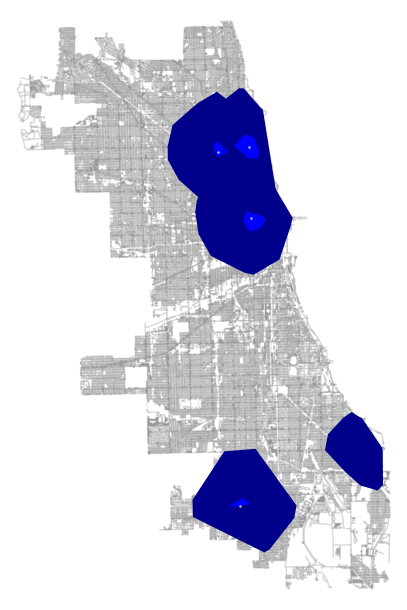

In [ ]:
fig, ax = plt.subplots(figsize=[5, 10])

plot_base_graph(city_data[CHI]["bike"], ax=ax)

for i, (cost, color) in enumerate(zip(reversed([0.50, 2, 5]), ["darkblue", "blue", "lightblue"])):
    isochrone_gdf[isochrone_gdf["cost"] == cost].plot(ax=ax, color=color, markersize=0.5)


Putting it together

In [80]:
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in metres between two (lat, lon) points."""
    R = 6_371_000
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a = sin(dphi / 2) ** 2 + cos(phi1) * cos(phi2) * sin(dlam / 2) ** 2
    return 2 * R * asin(sqrt(a))


def stops_within_walk(origin_lat, origin_lon, stops_df):
    """Return rows of stops_df within WALK_RADIUS_M of (origin_lat, origin_lon).
    Accepts GeoDataFrames (geometry column) or plain DataFrames (lat/lon columns).
    """
    stops_df = stops_df.copy()
    if "geometry" in stops_df.columns:
        stops_df["_lat"] = stops_df.geometry.y
        stops_df["_lon"] = stops_df.geometry.x
    else:
        stops_df["_lat"] = stops_df["lat"]
        stops_df["_lon"] = stops_df["lon"]
    stops_df["_dist_m"] = stops_df.apply(
        lambda r: haversine(origin_lat, origin_lon, r._lat, r._lon), axis=1
    )
    return stops_df[stops_df["_dist_m"] <= WALK_RADIUS_M].copy()


def nodes_within_walk(city, origin_point):
    """Return (node, Point) pairs reachable on foot from origin_point."""
    walk_graph    = city_data[city]["walk"]
    starting_node = ox.nearest_nodes(walk_graph, origin_point.x, origin_point.y)
    subgraph      = nx.ego_graph(walk_graph, starting_node,
                                 radius=WALK_RADIUS_M, distance="length")
    return [(node, Point(data["x"], data["y"]))
            for node, data in subgraph.nodes(data=True)]

In [116]:
def get_reachable_metra(station_name, budget):
    """Returns list of (lat, lon) for all Metra stops reachable within budget."""
    station      = metra_line_zones[metra_line_zones["name"] == station_name].iloc[0]
    zone         = station["zone"]
    station_lines = [l for l in LINE_COLS if station[l]]

    reachable = {}
    for line in station_lines:
        fare_mat = metra_line_zones[metra_line_zones[line]].copy()
        fare_mat["fare"] = fare_mat["zone"].apply(
            lambda z: metra_fare_graph[zone].get(z, {}).get("fare", None)
        )
        for name in fare_mat[fare_mat["fare"] <= budget]["name"].tolist():
            reachable[name] = metra_stop_coords[name]

    return list(reachable.values())


def get_reachable_cta_bus(stop_name, budget):
    """
    stop_name is public_nam, e.g. 'Cicero & Berteau'.
    Returns list of (lat, lon) for all reachable bus stops.
    """
    if budget < 2.25:
        reachable_stops = [stop_name]
    else:
        stop_lines     = set(bus_stops_dict[stop_name])
        reachable_lines = nx.Graph()
        for line in stop_lines:
            reachable_lines = nx.compose(
                reachable_lines, nx.ego_graph(bus_routes_graph, line, radius=2)
            )
        reachable_stops = list({
            stop
            for line in reachable_lines.nodes
            for stop in bus_routes_dict[line]
        })

    return [bus_stop_coords[s] for s in reachable_stops if s in bus_stop_coords]


def get_reachable_cta_l(station_name, budget):
    """
    station_name is station_descriptive_name, e.g. '18th (Pink Line)'.
    Returns list of (lat, lon) for all reachable L stations.
    """
    station_lines = l_station_to_lines_dict[station_name]

    if budget < 2.50 or (budget < 5.00 and "ORD" in station_lines):
        reachable_stations = [station_name]
    else:
        reachable_lines = nx.Graph()
        for line in station_lines:
            reachable_lines = nx.compose(
                reachable_lines, nx.ego_graph(l_lines_graph, line, radius=2)
            )
        reachable_stations = list({
            station
            for line in reachable_lines.nodes
            for station in l_lines_to_stations_dict.get(line, [])
        })

    return [l_stop_coords[s] for s in reachable_stations if s in l_stop_coords]


def get_reachable_divvy(station_name, budget):
    """
    station_name is station_na, e.g. 'Clark St & Montrose Ave'.
    Returns list of (lat, lon) for all reachable bike-graph nodes.
    """
    node      = divvy_station_to_node_dict[station_name]
    egograph  = nx.ego_graph(city_data[CHI]["bike"], node,
                              radius=budget, distance="time_s")
    bike_graph = city_data[CHI]["bike"]
    return [
        (bike_graph.nodes[n]["y"], bike_graph.nodes[n]["x"])
        for n in egograph.nodes()
    ]

In [117]:
def _reachable_for_mode(origin_lat, origin_lon, budget, stops_df, reach_fn, id_col):
    nearby = stops_within_walk(origin_lat, origin_lon, stops_df)
    all_coords = []
    for _, row in nearby.iterrows():
        all_coords.extend(reach_fn(row[id_col], budget))
    return list(set(all_coords))

def get_reachable_metra_from_origin(lat, lon, budget):
    return _reachable_for_mode(lat, lon, budget, metra_line_zones, get_reachable_metra, "name")

def get_reachable_bus_from_origin(lat, lon, budget):
    return _reachable_for_mode(lat, lon, budget, cta_bus_stops, get_reachable_cta_bus, "public_nam")

def get_reachable_l_from_origin(lat, lon, budget):
    return _reachable_for_mode(lat, lon, budget, l_stations, get_reachable_cta_l, "station_descriptive_name")

def get_reachable_divvy_from_origin(lat, lon, budget):
    return _reachable_for_mode(lat, lon, budget, divvy_stations, get_reachable_divvy, "station_na")

In [118]:
def get_reachable_all_modes(origin_lat, origin_lon, budget):
    all_coords = []
    for fn in [get_reachable_metra_from_origin, get_reachable_bus_from_origin,
               get_reachable_l_from_origin, get_reachable_divvy_from_origin]:
        all_coords.extend(fn(origin_lat, origin_lon, budget))
    return list(set(all_coords))

In [ ]:
# test individual functions
get_reachable_cta_bus("Kedzie & 48th Place", 5)
get_reachable_metra("University Park", 10)
get_reachable_divvy("Clark St & Montrose Ave", 3)
get_reachable_cta_l("O'Hare (Blue Line)", 6)

In [ ]:
import math
import functools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def _haversine_km_vec(origin_lat, origin_lon, lats, lons):
    """
    Vectorised haversine — returns a numpy array of distances in km.
    ~50-100x faster than a Python loop for large coord arrays.
    """
    R = 6371.0
    lat1 = math.radians(origin_lat)
    lon1 = math.radians(origin_lon)
    lats_r = np.radians(lats)
    lons_r = np.radians(lons)
    dlat = lats_r - lat1
    dlon = lons_r - lon1
    a = np.sin(dlat / 2) ** 2 + math.cos(lat1) * np.cos(lats_r) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))


# ---------------------------------------------------------------------------
# Walking-distance filter (used only for finding nearby *boarding* stops)
# ---------------------------------------------------------------------------

def filter_within_walk(origin_lat, origin_lon, coords, radius_m=WALK_RADIUS_M):
    """
    Filter (lat, lon) pairs to those within radius_m of the origin.
    Used to find reachable boarding stops — NOT applied to transit destinations.
    Uses a cheap bbox pre-filter then vectorised haversine for survivors.
    """
    if not coords:
        return []

    lats = np.array([c[0] for c in coords])
    lons = np.array([c[1] for c in coords])

    # Cheap bbox pre-filter
    delta_lat = radius_m / 111_320
    delta_lon = radius_m / (111_320 * math.cos(math.radians(origin_lat)))
    mask = (
        (lats >= origin_lat - delta_lat) & (lats <= origin_lat + delta_lat) &
        (lons >= origin_lon - delta_lon) & (lons <= origin_lon + delta_lon)
    )
    candidates = list(zip(lats[mask], lons[mask]))
    if not candidates:
        return []

    # Exact haversine only on bbox survivors
    c_lats = np.array([c[0] for c in candidates])
    c_lons = np.array([c[1] for c in candidates])
    dists  = _haversine_km_vec(origin_lat, origin_lon, c_lats, c_lons)
    radius_km = radius_m / 1000
    return [(lat, lon) for (lat, lon), d in zip(candidates, dists) if d <= radius_km]


# ---------------------------------------------------------------------------
# Caching for transit reachability (the expensive part)
# ---------------------------------------------------------------------------

@functools.lru_cache(maxsize=256)
def get_reachable_cached(origin_lat, origin_lon, budget):
    """
    Memoised wrapper around get_reachable_all_modes.
    Coordinates are rounded to ~11m precision to improve cache hit rate
    for nearby repeated calls (e.g. interactive map clicks).
    Call as: get_reachable_cached(round(lat, 4), round(lon, 4), budget)
    """
    return get_reachable_all_modes(origin_lat, origin_lon, budget)


# ---------------------------------------------------------------------------
# Plot (purely presentational — receives pre-computed coords)
# ---------------------------------------------------------------------------

def plot_reachable(origin_lat, origin_lon, coords, radius_m=WALK_RADIUS_M, graph=None):
    if graph is not None:
        fig, ax = plot_base_graph(graph)
    else:
        fig, ax = plt.subplots(figsize=(8, 8), facecolor="#1a1a2e")
        ax.set_facecolor("#1a1a2e")

    if coords:
        lats, lons = zip(*coords)
        ax.scatter(lons, lats,
                   s=10, color="#00a1de", alpha=0.7,
                   linewidths=0.5, edgecolors="#00a1de",
                   zorder=3)

    delta_lat = radius_m / 111_320
    delta_lon = radius_m / (111_320 * math.cos(math.radians(origin_lat)))
    ax.add_patch(mpatches.Ellipse(
        (origin_lon, origin_lat),
        width=2 * delta_lon, height=2 * delta_lat,
        linewidth=1.5, linestyle=(0, (5, 5)),
        edgecolor="white", facecolor="none",
        alpha=0.5, zorder=4,
    ))

    ax.scatter([origin_lon], [origin_lat],
               s=120, color="black", edgecolors="white",
               linewidths=2, zorder=5)

    ax.annotate(
        f"{len(coords)} reachable points",
        xy=(origin_lon, origin_lat),
        xytext=(origin_lon, origin_lat + delta_lat * 1.3),
        fontsize=9, fontfamily="monospace", fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.65, ec="none"),
        ha="center", zorder=6,
    )

    ax.tick_params(colors="gray", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")
    ax.set_xlabel("Longitude", color="gray", fontsize=8)
    ax.set_ylabel("Latitude", color="gray", fontsize=8)
    ax.set_aspect("equal", adjustable="datalim")

    all_lons = [origin_lon] + ([lon for _, lon in coords] if coords else [])
    all_lats = [origin_lat] + ([lat for lat, _ in coords] if coords else [])
    pad_lon = (max(all_lons) - min(all_lons)) * 0.1 or delta_lon * 2
    pad_lat = (max(all_lats) - min(all_lats)) * 0.1 or delta_lat * 2
    ax.set_xlim(min(all_lons) - pad_lon, max(all_lons) + pad_lon)
    ax.set_ylim(min(all_lats) - pad_lat, max(all_lats) + pad_lat)

    fig.tight_layout()
    return fig

In [122]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

# ---------------------------------------------------------------------------
# Color / style config per mode — extend as needed
# ---------------------------------------------------------------------------

MODE_STYLES = {
    "metra":   {"color": "#e05252", "size": 18,  "zorder": 5, "alpha": 0.9, "label": "metra"},
    "cta_bus": {"color": "#00b4d8", "size": 6,   "zorder": 3, "alpha": 0.7, "label": "cta_bus"},
    "cta_l":   {"color": "#90e0ef", "size": 14,  "zorder": 4, "alpha": 0.85,"label": "cta_l"},
    "divvy":   {"color": "#0077b6", "size": 4,   "zorder": 2, "alpha": 0.6, "label": "divvy"},
}

BG_COLOR    = "#111318"
STREET_COLOR = "#2a2d35"


def plot_isofare(
    origin_lat,
    origin_lon,
    coords_by_mode: dict,           
    budget: float = None,
    graph=None,               
    figsize=(6, 10),
    title: str = None,
    fig=None,
    ax=None,
):
    """
    Reproduce the isofare scatter-map style.

    Parameters
    ----------
    origin_lat, origin_lon : float
        Origin point shown as a white star.
    coords_by_mode : dict
        Keys are mode names (must match MODE_STYLES keys), values are
        lists of (lat, lon) tuples for reachable points.
    budget : float, optional
        Shown in the title if provided.
    graph : networkx.MultiDiGraph, optional
        OSMNx graph for the faint street underlay.
    figsize : tuple
        Figure size in inches.
    title : str, optional
        Custom title — overrides the auto-generated one.
    """
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=figsize, facecolor=BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    # --- street underlay ---
    if graph is not None:
        ox.plot_graph(
            graph,
            ax=ax,
            show=False,
            close=False,
            edge_color=STREET_COLOR,
            edge_alpha=0.4,
            edge_linewidth=0.3,
            node_size=0,
            bgcolor=BG_COLOR,
        )

    # --- scatter each mode ---
    legend_handles = []
    for mode, coords in coords_by_mode.items():
        if not coords:
            continue
        style = MODE_STYLES.get(mode, {"color": "#ffffff", "size": 6, "zorder": 3, "alpha": 0.7, "label": mode})
        lats, lons = zip(*coords)
        ax.scatter(
            lons, lats,
            s=style["size"],
            c=style["color"],
            alpha=style["alpha"],
            linewidths=0,
            zorder=style["zorder"],
        )
        legend_handles.append(
            mlines.Line2D(
                [], [],
                linestyle="none",
                marker="o",
                markersize=5,
                color=style["color"],
                label=style["label"],
            )
        )

    # --- origin star ---
    ax.scatter(
        [origin_lon], [origin_lat],
        s=180,
        marker="*",
        color="white",
        linewidths=0,
        zorder=10,
    )

    # --- legend ---
    if legend_handles:
        leg = ax.legend(
            handles=legend_handles,
            loc="upper right",
            frameon=True,
            framealpha=0.55,
            facecolor=BG_COLOR,
            edgecolor="#444",
            fontsize=8,
            labelcolor="white",
            markerscale=1.2,
            handletextpad=0.4,
            borderpad=0.6,
        )

    # --- title ---
    if title is None and budget is not None:
        title = f"Reachable for ${budget:.2f}"
    if title:
        ax.set_title(title, color="white", fontsize=10, pad=8, fontfamily="monospace")

    # --- axes cosmetics ---
    ax.tick_params(colors="#555", labelsize=6)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")
    ax.set_xlabel("Longitude", color="#555", fontsize=7)
    ax.set_ylabel("Latitude",  color="#555", fontsize=7)
    ax.set_aspect("equal", adjustable="datalim")

    # --- auto-zoom to data extent with padding ---
    all_lons = [origin_lon]
    all_lats = [origin_lat]
    for coords in coords_by_mode.values():
        if coords:
            lats, lons = zip(*coords)
            all_lons.extend(lons)
            all_lats.extend(lats)

    lon_range = max(all_lons) - min(all_lons) or 0.02
    lat_range = max(all_lats) - min(all_lats) or 0.02
    ax.set_xlim(min(all_lons) - lon_range * 0.05, max(all_lons) + lon_range * 0.05)
    ax.set_ylim(min(all_lats) - lat_range * 0.05, max(all_lats) + lat_range * 0.05)

    fig.tight_layout()
    return fig, ax

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


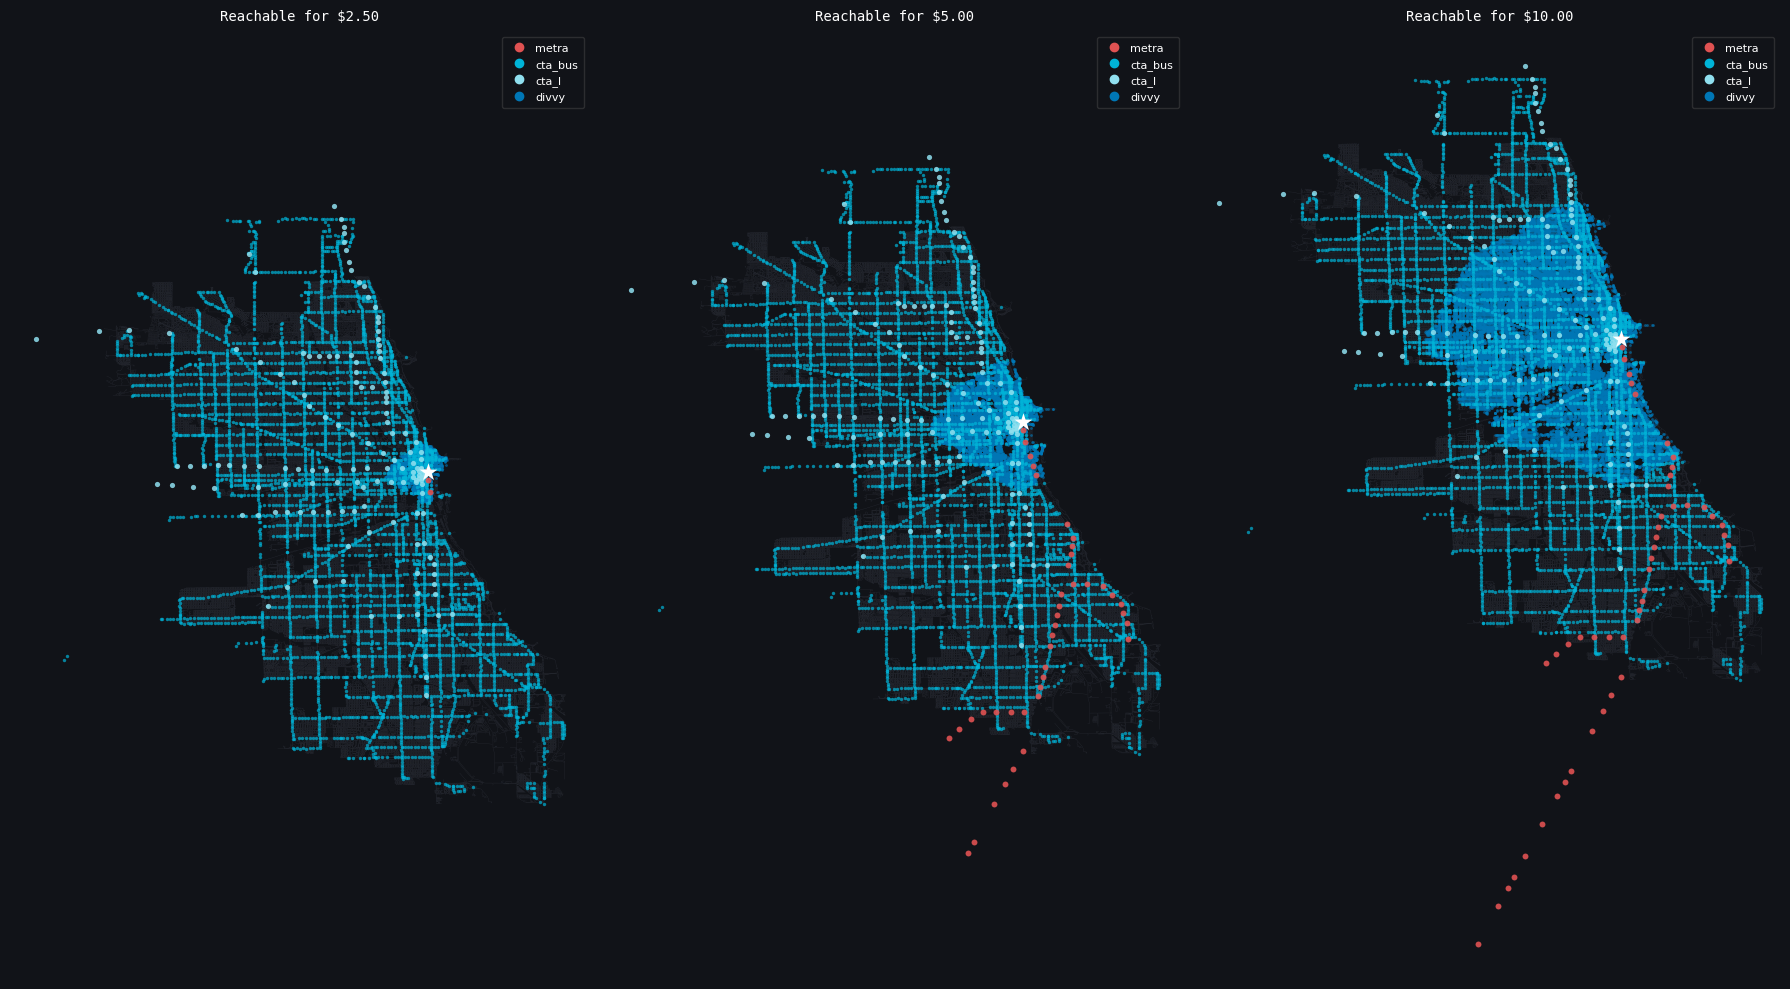

In [ ]:
origin_lat, origin_lon = 41.8827, -87.6233
budgets = [2.50, 5.00, 10.00]

coords_by_budget = {}
for budget in budgets:
    coords_by_budget[budget] = {
        "metra":   get_reachable_metra_from_origin(origin_lat, origin_lon, budget),
        "cta_bus": get_reachable_bus_from_origin(origin_lat, origin_lon, budget),
        "cta_l":   get_reachable_l_from_origin(origin_lat, origin_lon, budget),
        "divvy":   get_reachable_divvy_from_origin(origin_lat, origin_lon, budget),
    }

fig, axes = plt.subplots(1, 3, figsize=(18, 10), facecolor=BG_COLOR)

for ax, budget in zip(axes, budgets):
    plot_isofare(
        origin_lat, origin_lon,
        coords_by_mode=coords_by_budget[budget],
        budget=budget,
        graph=city_data[CHI]["walk"],
        fig=fig, ax=ax,   # pass in the existing ax
    )

fig.tight_layout()
fig.savefig("isofare_comparison.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)

### Lit Review

Relevant reading:
- [Chicago Riders’ Choice of Uber and Lyft over Transit Implies a Median Breakeven Value of Travel Time Equal to the Regional Hourly Wage of $30 per Hour](https://pubs.acs.org/doi/10.1021/acs.est.4c08808)
-  [Estimating the Impact of High-Frequency Public Transit on Employment Outcomes in Chicago Neighborhoods ](https://www.mdpi.com/2413-8851/10/4/208)